       CustomerID         Age      Income    Spending
count  200.000000  200.000000  200.000000  200.000000
mean   100.500000   38.850000   60.560000   50.200000
std     57.879185   13.969007   26.264721   25.823522
min      1.000000   18.000000   15.000000    1.000000
25%     50.750000   28.750000   41.500000   34.750000
50%    100.500000   36.000000   61.500000   50.000000
75%    150.250000   49.000000   78.000000   73.000000
max    200.000000   70.000000  137.000000   99.000000


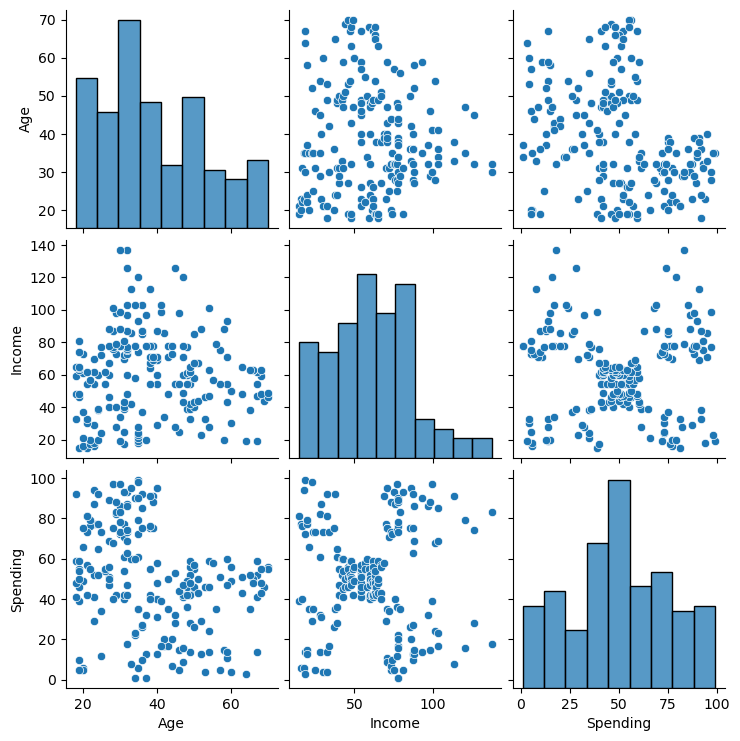

D:\anaconda\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


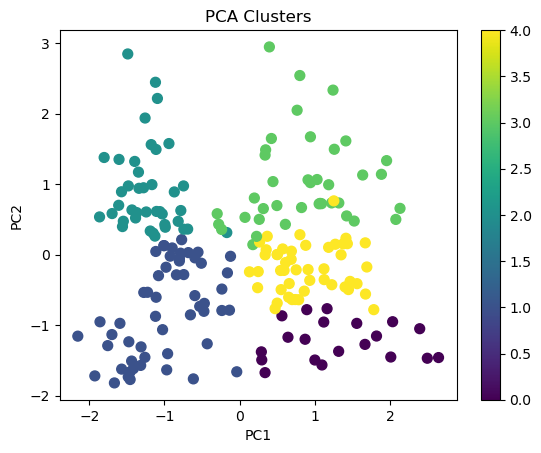

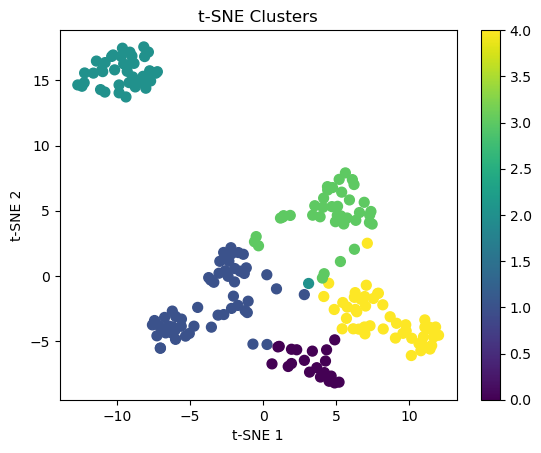


Cluster 0 | Avg Age: 46.2 | Avg Income: $26.8k | Avg Spending: 18.4
→ Strategy: Discount campaigns, engagement emails

Cluster 1 | Avg Age: 25.2 | Avg Income: $41.1k | Avg Spending: 62.2
→ Strategy: Cross-selling, personalized recommendations

Cluster 2 | Avg Age: 32.9 | Avg Income: $86.1k | Avg Spending: 81.5
→ Strategy: Premium loyalty programs, exclusive offers

Cluster 3 | Avg Age: 39.9 | Avg Income: $86.1k | Avg Spending: 19.4
→ Strategy: Discount campaigns, engagement emails

Cluster 4 | Avg Age: 55.6 | Avg Income: $54.4k | Avg Spending: 48.9
→ Strategy: Cross-selling, personalized recommendations


In [1]:
# task2_customer_segmentation.ipynb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Load & EDA
df = pd.read_csv('Mall_Customers.csv')
df.rename(columns={'Annual Income (k$)': 'Income', 'Spending Score (1-100)': 'Spending'}, inplace=True)
print(df.describe())
sns.pairplot(df[['Age','Income','Spending']]); plt.show()

# 2. K-Means Clustering
X = df[['Age','Income','Spending']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 3. PCA & t-SNE Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'], cmap='viridis', s=50)
plt.title('PCA Clusters'); plt.xlabel('PC1'); plt.ylabel('PC2'); plt.colorbar(); plt.show()

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=df['Cluster'], cmap='viridis', s=50)
plt.title('t-SNE Clusters'); plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2'); plt.colorbar(); plt.show()

# 4. Marketing Strategies per Segment
for cluster in range(5):
    sub = df[df['Cluster']==cluster]
    print(f"\nCluster {cluster} | Avg Age: {sub['Age'].mean():.1f} | Avg Income: ${sub['Income'].mean():.1f}k | Avg Spending: {sub['Spending'].mean():.1f}")
    # Example strategy mapping
    if sub['Spending'].mean() > 60 and sub['Income'].mean() > 70: print("→ Strategy: Premium loyalty programs, exclusive offers")
    elif sub['Spending'].mean() < 30: print("→ Strategy: Discount campaigns, engagement emails")
    else: print("→ Strategy: Cross-selling, personalized recommendations")